# День 08. Упражнение 02
# Мульти-классовая классификация. One-hot кодирование. Случайный лес

## 0. Импорты

In [ ]:
import pandas as pd
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.metrics import accuracy_score
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.multiclass import OneVsRestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
import matplotlib.pyplot as plt
import numpy as np
data = '../../datasets/checker_submits.csv'

## 1. Предобработка


1. Прочитай файл [`checker-submits.csv`](https://drive.google.com/file/d/14voc4fNJZiLEFaZyd8nEG-lQt5JjatYw/view?usp=sharing).
2. Создай DataFrame `df` с колонками: `uid`, `labname`, `numTrials`, `hour`, `dayofweek`, где `hour` извлекается из `timestamp`, а также `dayofweek` (`0` — понедельник, `6` — воскресенье). Мы будем пытаться предсказать день недели, имея данные о том, какой пользователь сделал коммит, для какой лабораторной, в какой час и с какой попытки.
3. С помощью `OneHotEncoder()` преобразуй категориальные признаки, затем удали из DataFrame исходные столбцы.
4. Используй `StandardScaler()` и нормализуй числовые признаки.
5. Сохрани DataFrame как `dayofweek.csv`.
6. Перед тем как пробовать разные алгоритмы, вычисли точность наивного алгоритма — того, который предсказывает всё как самый частый класс.


In [ ]:
df_row = pd.read_csv(data)
df_row['timestamp'] = pd.to_datetime(df_row['timestamp'])

df_row['hour'] = df_row['timestamp'].dt.hour
df_row['dayofweek'] = df_row['timestamp'].dt.day_of_week
df = df_row.copy()
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1686 entries, 0 to 1685
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   uid        1686 non-null   str           
 1   labname    1686 non-null   str           
 2   numTrials  1686 non-null   int64         
 3   timestamp  1686 non-null   datetime64[us]
 4   hour       1686 non-null   int32         
 5   dayofweek  1686 non-null   int32         
dtypes: datetime64[us](1), int32(2), int64(1), str(2)
memory usage: 66.0 KB


In [ ]:
encoder_uid = OneHotEncoder(sparse_output=False)
encoder_labname = OneHotEncoder(sparse_output=False)
scaler = StandardScaler()

In [ ]:
uid_encoded = encoder_uid.fit_transform(df[['uid']])
labname_encoded = encoder_labname.fit_transform(df[['labname']])


uid_df = pd.DataFrame(uid_encoded, columns=encoder_uid.get_feature_names_out(['uid']))
labname_df = pd.DataFrame(labname_encoded, columns=encoder_labname.get_feature_names_out(['labname']))


df = pd.concat([df, uid_df, labname_df], axis=1)
df.drop(['uid', 'labname', 'timestamp'], axis=1, inplace=True)


In [ ]:
df[['numTrials', 'hour']] = scaler.fit_transform(df[['numTrials', 'hour']])

In [ ]:
df.to_csv('dayofweek.csv')
df

,numTrials,hour,dayofweek,uid_user_0,uid_user_1,uid_user_10,uid_user_11,uid_user_12,uid_user_13,uid_user_14,...,labname_lab02,labname_lab03,labname_lab03s,labname_lab05s,labname_laba04,labname_laba04s,labname_laba05,labname_laba06,labname_laba06s,labname_project1
0,-0.788667,-2.562352,4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
1,-0.756764,-2.562352,4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
2,-0.724861,-2.562352,4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
3,-0.692958,-2.562352,4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
4,-0.661055,-2.562352,4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1681,-0.533442,0.945382,3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
1682,-0.629151,0.945382,3,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
1683,-0.597248,0.945382,3,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
1684,-0.565345,0.945382,3,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0


In [ ]:
X = df.drop('dayofweek', axis=1)
y = df['dayofweek']

In [ ]:
most_frequent = y.mode()[0]
naive_pred = [most_frequent] * len(y)
naive_accuracy = accuracy_score(y, naive_pred)
naive_accuracy

0.23487544483985764

## 2. Алгоритмы


### a. Логистическая регрессия

1. Обучи логистическую регрессию; для базовой модели используй `random_state=21`, `fit_intercept=False`.
2. Вычисли точность (accuracy).
3. Напиши функцию, которая строит график (`barh`), принимая коэффициенты обученной модели, имена признаков и количество `top-n` наиболее важных признаков для отображения.
4. Построй график (`barh`) для базовой модели с 10 самыми важными признаками (по абсолютному значению) для обученной модели.
5. Помни, что это мульти-классовая классификация, и `coef_` возвращает матрицу — чтобы вычислить важность признака, нужно просуммировать все индивидуальные значения важности этого признака для всех целевых классов.

In [ ]:
model = LogisticRegression( random_state=21, fit_intercept=False)

In [ ]:
model.fit(X,y)

,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",False
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",21
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solv

In [ ]:
accuracy = accuracy_score(y, model.predict(X) )
accuracy

0.6405693950177936

### Функция для отображения графиков 

In [ ]:
def plot_top_features(importance, feature_names, top_n=10):
    sorted_idx = np.argsort(np.abs(importance))[::-1][:top_n]
    top_importance = importance[sorted_idx]
    top_names = np.array(feature_names)[sorted_idx]
    
    colors = ['red' if c > 0 else 'blue' for c in top_importance]
    
    plt.figure(figsize=(10, 6))
    plt.barh(range(len(top_importance)), top_importance, color=colors)
    plt.yticks(range(len(top_importance)), top_names)
    plt.xlabel('Coefficient value')
    plt.title(f'Top-{top_n} most important features')
    plt.axvline(x=0, color='black', linestyle='-', linewidth=0.5)
    plt.grid(axis='x', alpha=0.3)
    plt.tight_layout()
    plt.show()

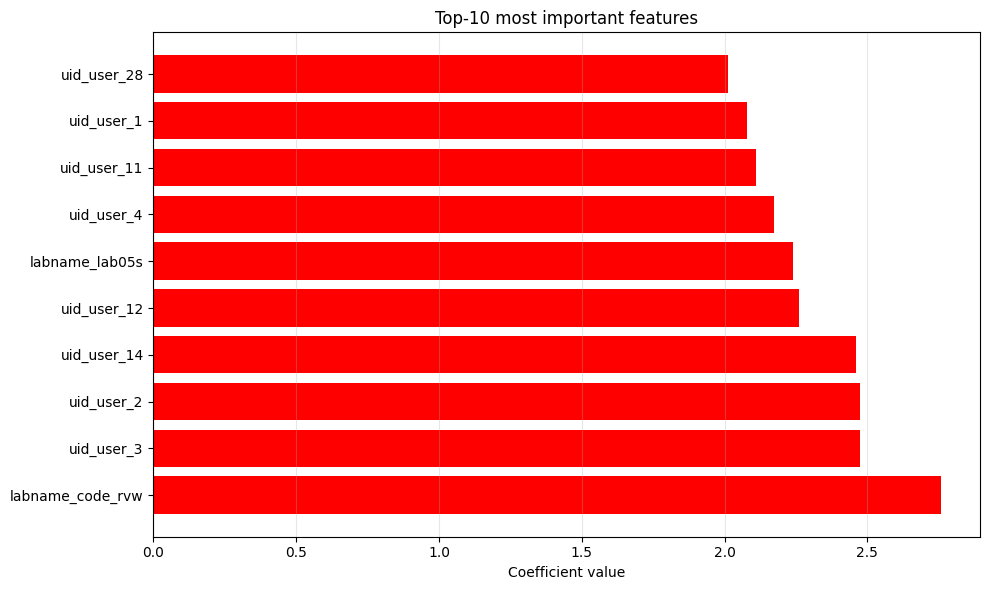

In [ ]:
importance_lr = np.max(np.abs(model.coef_), axis=0)
plot_top_features(importance_lr, X.columns, 10)

### b. SVC

1. Обучи модель `SVC`; для базовой модели используй параметры `kernel='linear'`, `probability=True`, `random_state=21`.
2. Попробуй разные ядра, вычисли точности.
3. Построй график (`barh`) для базовой модели с 10 самыми важными признаками (по абсолютному значению) для обученной модели с линейным ядром.*

*По умолчанию SVC использует стратегию “one vs one” для классификации, поэтому в `coef_` возвращает матрицу. Чтобы вычислить важность признака, нужно использовать [OneVsRestClassifier](https://scikit-learn.org/stable/modules/generated/sklearn.multiclass.OneVsRestClassifier.html) поверх SVC и просуммировать все индивидуальные значения важности признака для всех целевых классов.

In [ ]:
model_svc = SVC(kernel='linear', probability=True, random_state=21)

In [ ]:
model_svc.fit(X, y)

/home/mnemokae/Desktop/School21_projects/DSB10_Intro_to_ML.ID_1577653-1/mnemokae/lib/python3.13/site-packages/sklearn/svm/_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'linear'
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide <scores_probabilities>`...deprecated:: 1.9 The `probability` parameter is deprecated and will be removed in 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`.",True
,"random_state random_state: int, RandomState instance or None, default=NoneControls the pseudo random number generation for shuffling the data forprobability estimates. Ignored when `probability` is False.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",21
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide <shrinking_svm>`.",True
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None


In [ ]:
accuracy_svc = accuracy_score(y, model_svc.predict(X))
accuracy_svc

0.702846975088968

/home/mnemokae/Desktop/School21_projects/DSB10_Intro_to_ML.ID_1577653-1/mnemokae/lib/python3.13/site-packages/sklearn/svm/_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
/home/mnemokae/Desktop/School21_projects/DSB10_Intro_to_ML.ID_1577653-1/mnemokae/lib/python3.13/site-packages/sklearn/svm/_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
/home/mnemokae/Desktop/School21_projects/DSB10_Intro_to_ML.ID_1577653-1/mnemokae/lib/python3.13/site-packages/sklearn/svm/_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probabilit

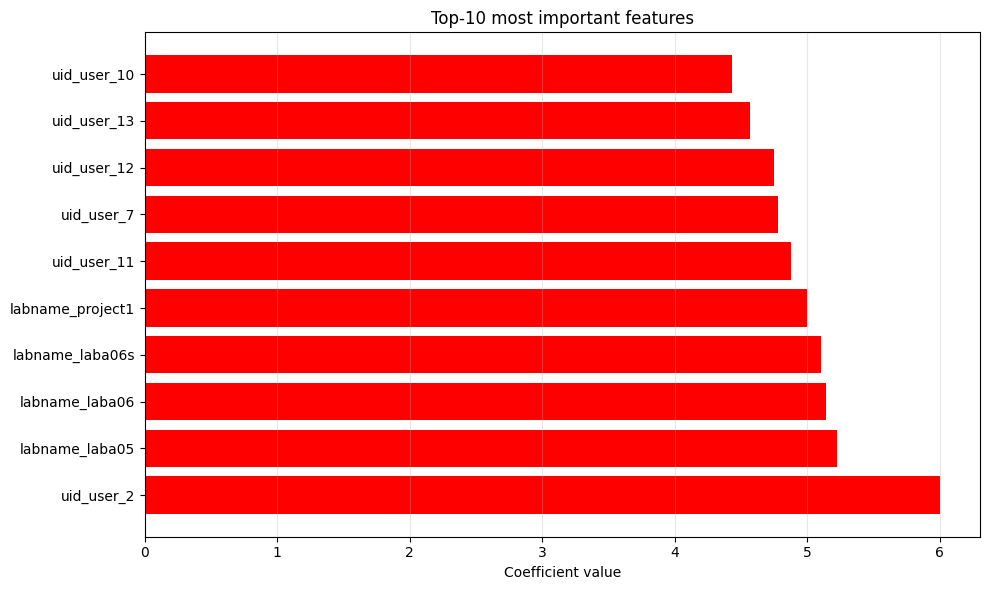

In [ ]:

model_svc_ovr = OneVsRestClassifier(SVC(kernel='linear', probability=True, random_state=21))
model_svc_ovr.fit(X, y)


coefs = np.vstack([estimator.coef_ for estimator in model_svc_ovr.estimators_])


feature_importance_svc = np.sum(np.abs(coefs), axis=0)

plot_top_features(feature_importance_svc, X.columns, 10)

### c. Дерево решений

1. Обучи `DecisionTreeClassifier`; для базовой модели используй `max_depth=4`, `random_state=21`.
2. Попробуй разные значения `max_depth`, вычисли точности.
3. Построй график (`barh`) для базовой модели с 10 самыми важными признаками (по абсолютному значению) для обученной модели, используя написанную функцию.

In [ ]:
model_dtc = DecisionTreeClassifier(max_depth=4, random_state=21)
model_dtc.fit(X,y)
accuracy_dtc = accuracy_score(y, model_dtc.predict(X))
accuracy_dtc

0.5516014234875445

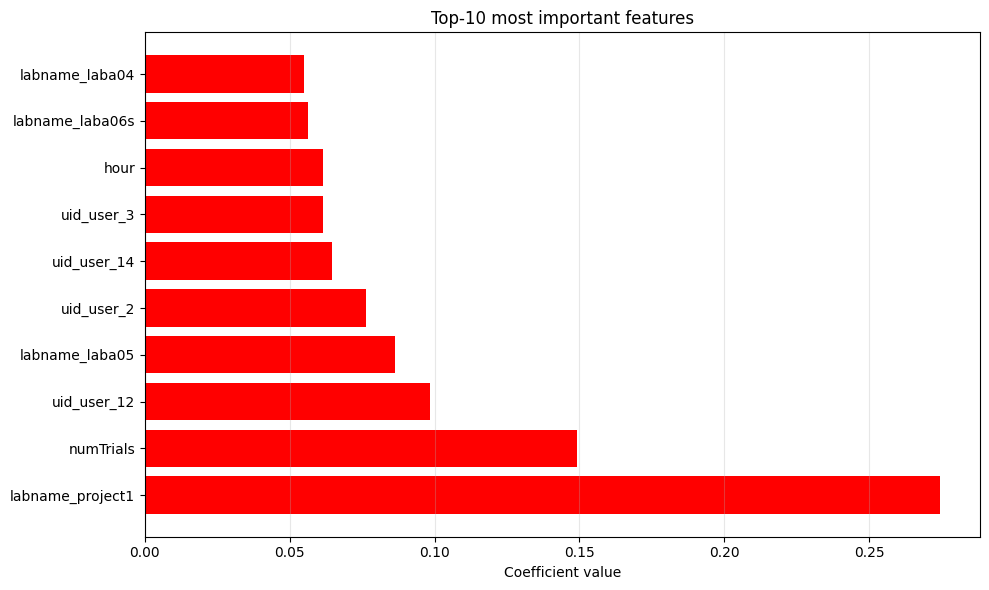

In [ ]:
feature_importance_tree = model_dtc.feature_importances_
plot_top_features(feature_importance_tree, X.columns, 10)

### d. Случайный лес

В реальной жизни лес состоит из множества деревьев. То же самое и в машинном обучении: случайный лес — это набор отдельных деревьев решений (подробнее см. документацию).

1. Обучи `RandomForestClassifier`; для базовой модели используй параметры `n_estimators=100`, `max_depth=25`, `random_state=21`.
2. Попробуй разные значения `max_depth` и `n_estimators`, вычисли точности.
3. Построй график (`barh`) для базовой модели с 10 самыми важными признаками (по абсолютному значению) для обученной модели, используя написанную функцию.

In [ ]:
model_rfc = RandomForestClassifier(n_estimators=100, max_depth=25, random_state=21)
model_rfc.fit(X, y)
accuracy_rfc = accuracy_score(y, model_rfc.predict(X))
accuracy_rfc

1.0

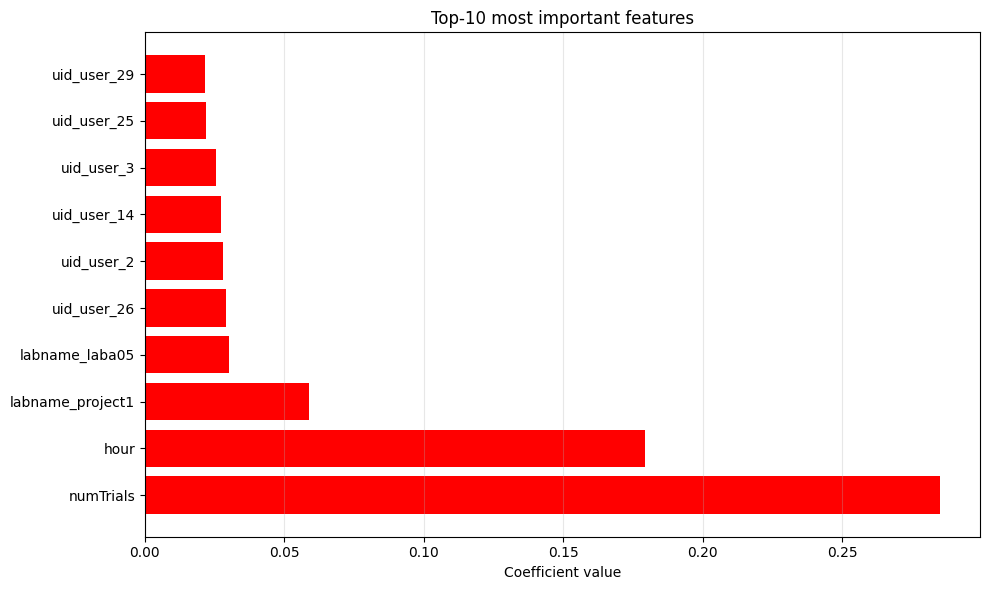

In [ ]:
feature_importance_rf = model_rfc.feature_importances_
plot_top_features(feature_importance_rf, X.columns, 10)